# The Family of Antiderivatives


In [25]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams

rcParams.update({
    "font.family": "serif",
    "font.size": 14,
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "legend.fontsize": 12,
    "figure.facecolor": "white",
})

NAVY = "#0F1934"
GOLD = "#BF9B3A"
CREAM = "#FCFAF5"
COLORS = ["#1F4E79", "#BF9B3A", "#0F6E56", "#993C1D", "#7B2D8B"]

x = np.linspace(-2.5, 2.5, 400)

def make_axes(title=""):
    fig, ax = plt.subplots(figsize=(8, 5))
    fig.patch.set_facecolor(CREAM)
    ax.set_facecolor(CREAM)
    ax.axhline(0, color="grey", linewidth=0.5)
    ax.axvline(0, color="grey", linewidth=0.5)
    ax.grid(True, alpha=0.15)
    ax.set_xlabel("$x$")
    ax.set_ylabel("$y$")
    if title:
        ax.set_title(title, color=NAVY)
    return fig, ax

## Step 1: Start with a function we know

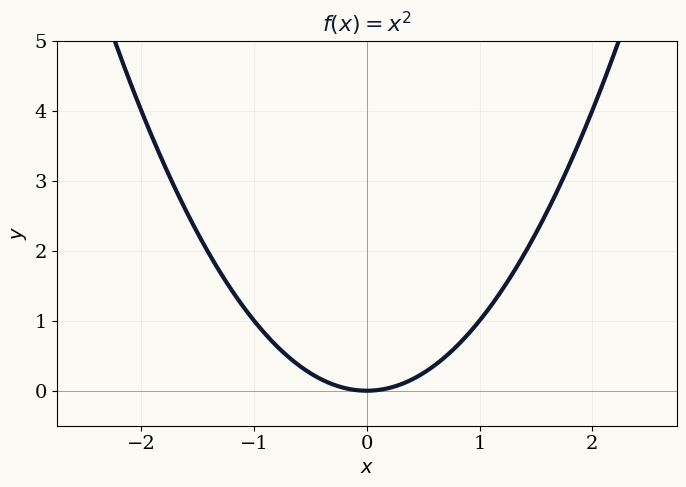

In [26]:
fig, ax = make_axes(r"$f(x) = x^2$")
ax.plot(x, x**2, color=NAVY, linewidth=3)
ax.set_ylim(-0.5, 5)
plt.show()

## Step 2: One antiderivative

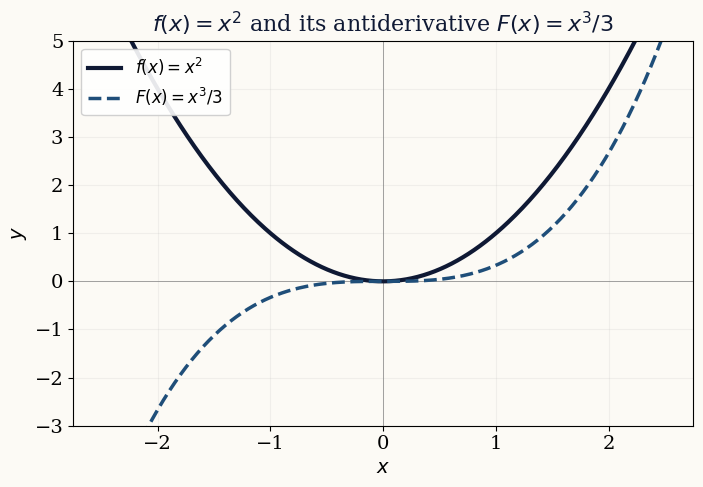

In [27]:
fig, ax = make_axes(r"$f(x) = x^2$ and its antiderivative $F(x) = x^3/3$")
ax.plot(x, x**2, color=NAVY, linewidth=3, label=r"$f(x) = x^2$")
ax.plot(x, x**3 / 3, color=COLORS[0], linewidth=2.5, linestyle="--",
        label=r"$F(x) = x^3/3$")
ax.set_ylim(-3, 5)
ax.legend(loc="upper left", framealpha=0.9)
plt.show()

## Step 3: But wait — is that the *only* antiderivative?

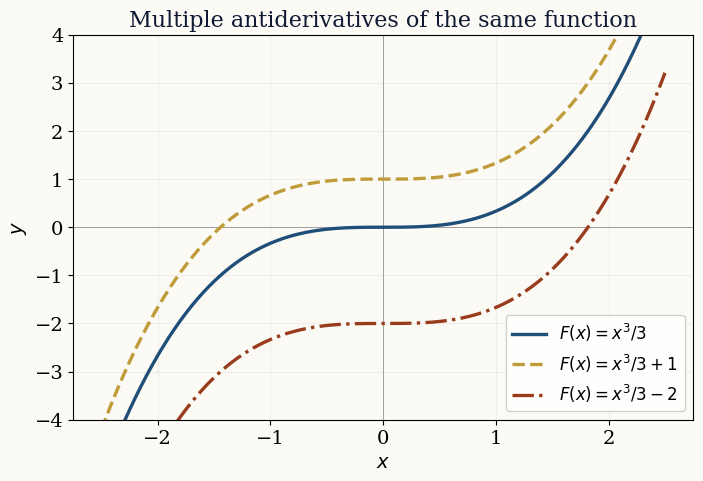

In [28]:
fig, ax = make_axes("Multiple antiderivatives of the same function")

for c, color, style in [( 0, COLORS[0], "-"),
                         ( 1, COLORS[1], "--"),
                         (-2, COLORS[3], "-.")]:
    sign = f"+ {c}" if c > 0 else f"- {-c}" if c < 0 else ""
    label = rf"$F(x) = x^3/3 {sign}$"
    ax.plot(x, x**3 / 3 + c, color=color, linewidth=2.4,
            linestyle=style, label=label)

ax.set_ylim(-4, 4)
ax.legend(loc="lower right", framealpha=0.9)

plt.show()

## Step 4: The whole family

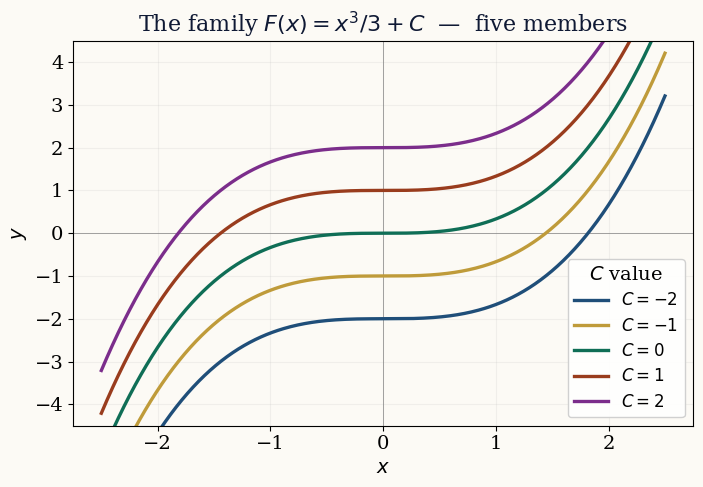

In [29]:
C_values = [-2, -1, 0, 1, 2]

fig, ax = make_axes(
    r"The family $F(x) = x^3/3 + C$  —  five members")

for c, color in zip(C_values, COLORS):
    sign = f"+ {c}" if c > 0 else f"- {-c}" if c < 0 else ""
    label = rf"$C = {c}$"
    ax.plot(x, x**3 / 3 + c, color=color, linewidth=2.4, label=label)

ax.set_ylim(-4.5, 4.5)
ax.legend(title="$C$ value", loc="lower right", framealpha=0.9)
plt.show()

## Step 5: Same slope everywhere


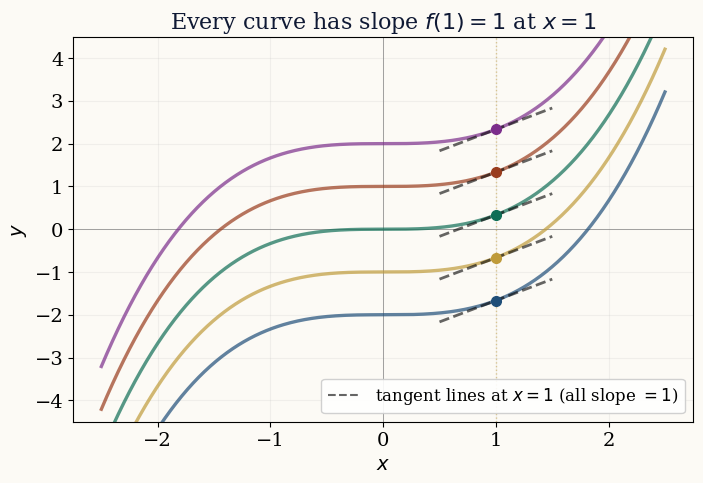

In [30]:
fig, ax = make_axes(
    r"Every curve has slope $f(1) = 1$ at $x = 1$")

for c, color in zip(C_values, COLORS):
    ax.plot(x, x**3 / 3 + c, color=color, linewidth=2.4, alpha=0.7)

slope = 1.0  # f(1) = 1
dx = 0.5
for c, color in zip(C_values, COLORS):
    y_at_1 = 1.0 / 3 + c
    ax.plot([1 - dx, 1 + dx],
            [y_at_1 - slope * dx, y_at_1 + slope * dx],
            color="black", linewidth=2, linestyle="--", alpha=0.6)
    ax.plot(1, y_at_1, "o", color=color, markersize=7, zorder=5)

ax.plot([], [], "k--", alpha=0.6,
        label=r"tangent lines at $x = 1$ (all slope $= 1$)")

ax.axvline(1, color=GOLD, linewidth=1, linestyle=":", alpha=0.5)
ax.set_ylim(-4.5, 4.5)
ax.legend(loc="lower right", framealpha=0.9)
plt.show()

## Step 6: Side by side — the family and their common derivative

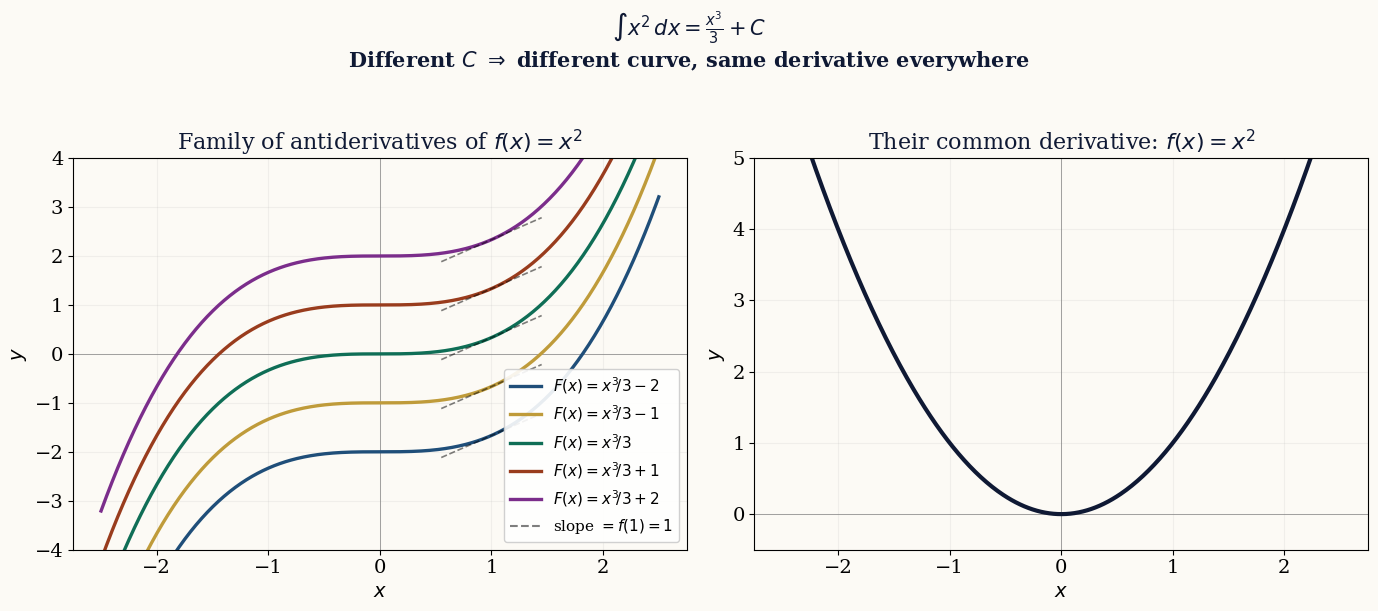

In [31]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor(CREAM)

for ax in (ax1, ax2):
    ax.set_facecolor(CREAM)
    ax.axhline(0, color="grey", linewidth=0.5)
    ax.axvline(0, color="grey", linewidth=0.5)
    ax.grid(True, alpha=0.15)
    ax.set_xlabel("$x$")
    ax.set_ylabel("$y$")

# Left: the family
for c, color in zip(C_values, COLORS):
    sign = f"+ {c}" if c > 0 else f"- {-c}" if c < 0 else ""
    ax1.plot(x, x**3 / 3 + c, color=color, linewidth=2.4,
             label=rf"$F(x) = x^3\!/3 {sign}$")

dx = 0.45
for c, color in zip(C_values, COLORS):
    y1 = 1.0 / 3 + c
    ax1.plot([1 - dx, 1 + dx],
             [y1 - 1.0 * dx, y1 + 1.0 * dx],
             color="black", linewidth=1.2, linestyle="--", alpha=0.5)
ax1.plot([], [], "k--", alpha=0.5, label=r"slope $= f(1) = 1$")
ax1.set_title(r"Family of antiderivatives of $f(x) = x^2$", color=NAVY)
ax1.set_ylim(-4, 4)
ax1.legend(loc="lower right", framealpha=0.9, fontsize=11)

# Right: the common derivative
ax2.plot(x, x**2, color=NAVY, linewidth=3)
ax2.set_title(r"Their common derivative: $f(x) = x^2$", color=NAVY)
ax2.set_ylim(-0.5, 5)

fig.suptitle(
    r"$\int x^2\,dx = \frac{x^3}{3} + C$"
    "\n"
    r"Different $C$ $\Rightarrow$ different curve, same derivative everywhere",
    fontsize=15, y=1.02, color=NAVY, fontweight="bold")

plt.tight_layout()
plt.show()

## Step 7: Why $+C$ cancels in definite integrals

In [32]:
a, b = 0, 2

print("Computing  ∫₀² x² dx  using different antiderivatives:\n")
print(f"{'C':>5}   {'F(2)':>12}   {'F(0)':>12}   {'F(2)−F(0)':>12}")
print("─" * 50)

for c in [-10, -2, -1, 0, 1, 2, 100]:
    F_b = b**3 / 3 + c
    F_a = a**3 / 3 + c
    result = F_b - F_a
    print(f"{c:>5}   {F_b:>12.4f}   {F_a:>12.4f}   {result:>12.4f}")

print(f"\n→  The answer is always 8/3 ≈ {8/3:.4f}, no matter what C is.")

Computing  ∫₀² x² dx  using different antiderivatives:

    C           F(2)           F(0)      F(2)−F(0)
──────────────────────────────────────────────────
  -10        -7.3333       -10.0000         2.6667
   -2         0.6667        -2.0000         2.6667
   -1         1.6667        -1.0000         2.6667
    0         2.6667         0.0000         2.6667
    1         3.6667         1.0000         2.6667
    2         4.6667         2.0000         2.6667
  100       102.6667       100.0000         2.6667

→  The answer is always 8/3 ≈ 2.6667, no matter what C is.


## Step 8: See it graphically

Pick any curve from the family. The *vertical distance* $F(2) - F(0)$ is the same for all of them — because they're just vertical shifts of each other.

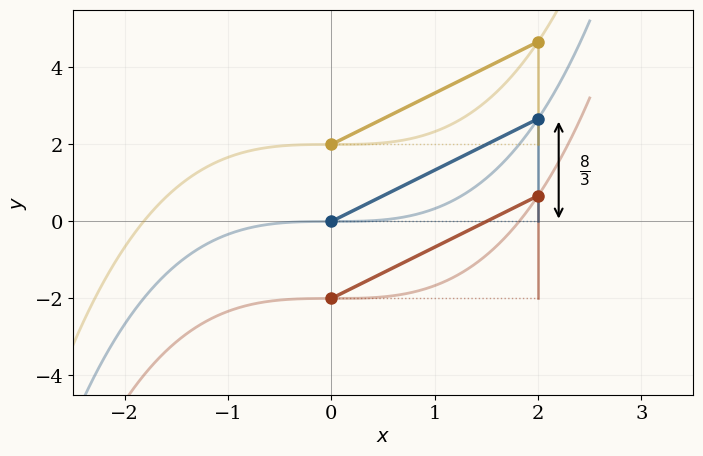

In [33]:
fig, ax = make_axes()

curves = [(-2, COLORS[3]), (0, COLORS[0]), (2, COLORS[1])]

for c, color in curves:
    ax.plot(x, x**3 / 3 + c, color=color, linewidth=2, alpha=0.35)

    F_0 = 0 + c
    F_2 = 8 / 3 + c

    ax.plot(0, F_0, "o", color=color, markersize=8, zorder=5)
    ax.plot(2, F_2, "o", color=color, markersize=8, zorder=5)

    # secant line (0,F(0)) → (2,F(2)) — all parallel
    ax.plot([0, 2], [F_0, F_2], color=color, linewidth=2.5,
            alpha=0.85, zorder=4)

    # right-angle bracket: horizontal baseline + vertical rise
    ax.plot([0, 2], [F_0, F_0], color=color,
            linewidth=1, linestyle=":", alpha=0.5)
    ax.plot([2, 2], [F_0, F_2], color=color,
            linewidth=1.8, linestyle="-", alpha=0.6)

# label the rise on the middle curve (C = 0)
ax.annotate("", xy=(2.2, 8/3), xytext=(2.2, 0),
            arrowprops=dict(arrowstyle="<->", color="black", lw=1.5))
ax.text(2.4, 8/6, r"$\frac{8}{3}$",
        fontsize=16, color="black", va="center", fontweight="bold")

ax.set_ylim(-4.5, 5.5)
ax.set_xlim(-2.5, 3.5)
plt.show()